### EX: Classifying Radar Profiles (LogReg vs. QDA vs. SVM)

In this exercise, we will tackle a highly non-linear problem by classifying simulated radar cross-sections. We will compare three different algorithms to understand their geometric limitations. You will execute the following steps:

* **Generate Data:** Create a non-linear dataset representing overlapping flight envelopes (a tight ring of adversarial returns nested within a larger ring of friendly returns).

* **Split Data:** Divide the radar data into training and testing sets.

* **Train Models:** Train a Linear model (Logistic Regression), a Quadratic model (QDA), and an advanced non-linear model (SVM with an RBF kernel).

* **Visualize Boundaries:** Plot the test data points overlaying the decision boundaries for all three models side-by-side to see exactly how they attempt to separate the classes.


In [1]:
!pip install --upgrade pip
!pip install numpy matplotlib scikit-learn pandas

Sample Radar Cross-Section Data:
   Radar_Return_Angle_1  Radar_Return_Angle_2  Target_Class
0             -0.469186              0.247915             1
1             -0.067487              1.006769             0
2             -0.443065              0.027383             1
3             -0.611725             -0.631407             0
4             -0.789013              0.684519             0 



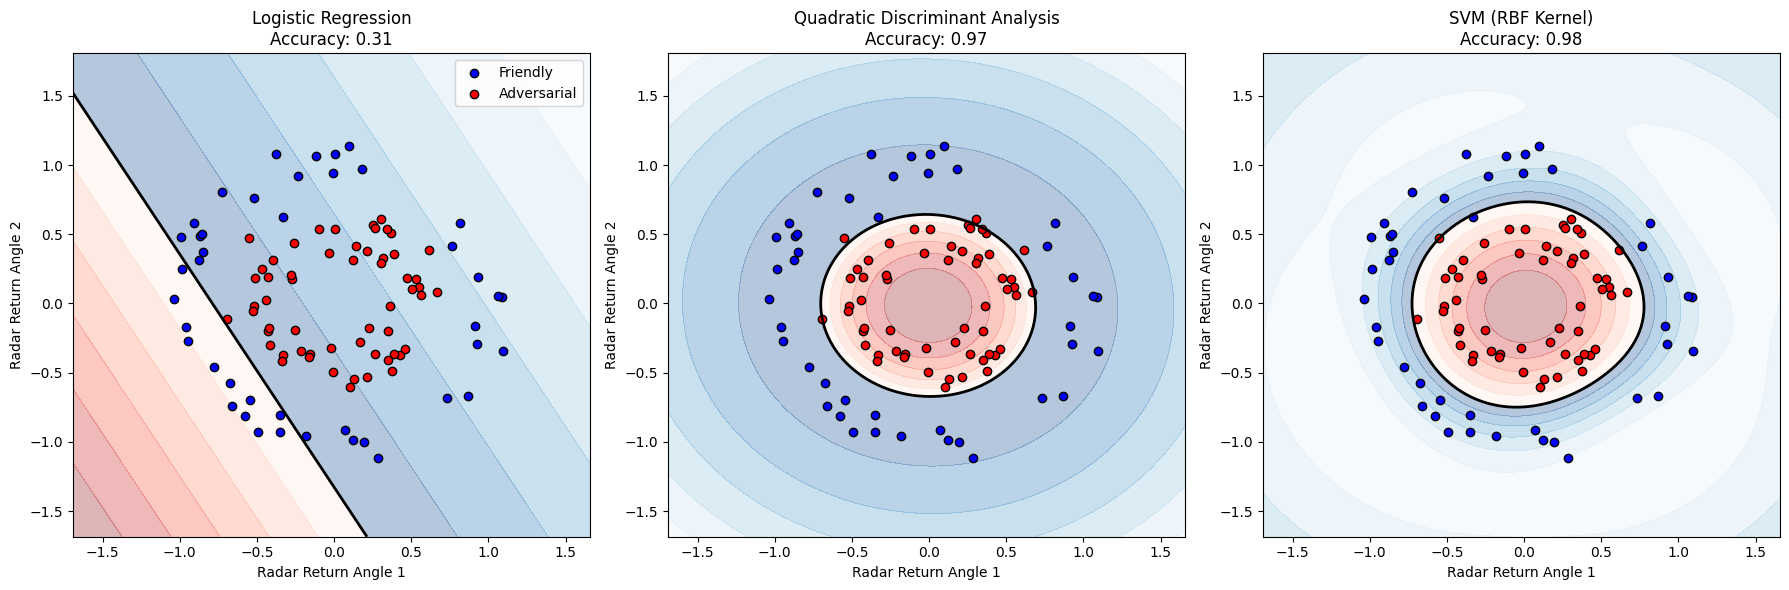

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# 1. Generate Non-Linear Radar Data (Concentric circles representing flight envelopes)
X_radar, y_radar = make_circles(n_samples=500, noise=0.1, factor=0.5, random_state=42)

df_radar = pd.DataFrame(X_radar, columns=['Radar_Return_Angle_1', 'Radar_Return_Angle_2'])
df_radar['Target_Class'] = y_radar # 0: Friendly, 1: Adversarial
print("Sample Radar Cross-Section Data:")
print(df_radar.head(), "\n")

# Split the data
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_radar, y_radar, test_size=0.2, random_state=42)

# 2. Train the Models
log_reg = LogisticRegression().fit(X_train_r, y_train_r)
qda = QuadraticDiscriminantAnalysis().fit(X_train_r, y_train_r)
svm = SVC(kernel='rbf', C=1.0).fit(X_train_r, y_train_r)

# 3. Prepare the Meshgrid for Plotting Decision Boundaries
xx, yy = np.meshgrid(np.linspace(X_radar[:,0].min()-0.5, X_radar[:,0].max()+0.5, 100),
                     np.linspace(X_radar[:,1].min()-0.5, X_radar[:,1].max()+0.5, 100))

models = [log_reg, qda, svm]
titles = ['Logistic Regression', 'Quadratic Discriminant Analysis', 'SVM (RBF Kernel)']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 4. Plot each model's decision boundary
for i, ax in enumerate(axes):
    model = models[i]
    
    # Calculate decision function or probabilities
    if hasattr(model, "decision_function"):
        Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    else:
        Z = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1] - 0.5
        
    Z = Z.reshape(xx.shape)
    
    # Draw contours
    ax.contourf(xx, yy, Z, levels=np.linspace(Z.min(), 0, 7), cmap='Blues', alpha=0.3) # Friendly Zone
    ax.contourf(xx, yy, Z, levels=np.linspace(0, Z.max(), 7), cmap='Reds', alpha=0.3) # Adversarial Zone
    ax.contour(xx, yy, Z, levels=[0], linewidths=2, colors='black') # Decision Boundary
    
    # Scatter test data
    ax.scatter(X_test_r[y_test_r == 0, 0], X_test_r[y_test_r == 0, 1], color='blue', label='Friendly', edgecolors='k')
    ax.scatter(X_test_r[y_test_r == 1, 0], X_test_r[y_test_r == 1, 1], color='red', label='Adversarial', edgecolors='k')
    
    acc = accuracy_score(y_test_r, model.predict(X_test_r))
    ax.set_title(f"{titles[i]}\nAccuracy: {acc:.2f}")
    ax.set_xlabel('Radar Return Angle 1')
    ax.set_ylabel('Radar Return Angle 2')

axes[0].legend(loc='upper right')
plt.tight_layout()
plt.show()

### Interpreting the Results 

The `make_circles` dataset simulates a complex combat scenario where adversarial radar returns (red dots) are nested tightly inside the flight envelope of friendly returns (blue dots). Look at the three plots to understand the limitations and strengths of our algorithms:

1. **Logistic Regression (Fails):** This is a linear classifier. It attempts to draw a single, straight line through the data. Because you cannot separate a donut hole from its outer ring with a straight line, the model is essentially guessing, resulting in near 50% accuracy.

2. **Quadratic Discriminant Analysis (Succeeds, but with a caveat):** Wait, how did a statistical model draw a perfect circle? QDA calculates the center point (mean) and the spread (variance) of each class. It realizes both classes share the exact same center at (0,0). However, it sees the adversarial returns are tightly clustered (low variance) and the friendly returns are widely spread out (high variance). By allowing independent variances, the resulting mathematical boundary forms a circle! *The caveat:* QDA assumes the friendly class is a giant, solid Gaussian blob, not a hollow ring. It works perfectly for concentric circles, but will fail on interlocking shapes (like crescent moons) where the variance isn't perfectly symmetrical.

3. **Support Vector Machine (Succeeds):** The SVM plot visually demonstrates the absolute power of the **Kernel Trick**. Unlike QDA, the SVM does not assume the data is shaped like a Gaussian bell curve. By using an RBF kernel, it maps the data based purely on geometric distances, cleanly projecting the data into a higher dimension to draw its boundary.

**The Tactical Takeaway:** While QDA survived this specific concentric scenario by relying on variance differences, SVM provides the true mathematical flexibility required for unpredictable, non-symmetrical combat data.